# Notebook 14 – EDA Mini Challenge
### Independent EDA on an unlabeled dataset

No instructions or data dictionary were given with `healthcare_dataset.csv`. This notebook explores it from scratch, step by step.


## 1. Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

df = pd.read_csv('healthcare_dataset.csv')
df.shape


(55500, 15)

## 2. Understand the Dataset

Column names suggest hospital admission records: patient demographics, condition, doctor/hospital, insurance, billing, room, dates, medication, and test results. No column is marked as a target.

In [2]:
df.columns.tolist()


['Name',
 'Age',
 'Gender',
 'Blood Type',
 'Medical Condition',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Insurance Provider',
 'Billing Amount',
 'Room Number',
 'Admission Type',
 'Discharge Date',
 'Medication',
 'Test Results']

## 3. Inspect the Structure

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [4]:
df.sample(5, random_state=1)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
32354,MichAel MILLs,63,Male,O-,Cancer,2023-06-30,Ronald Gordon,Weber-Mcpherson,Medicare,47417.999804,387,Elective,2023-07-06,Paracetamol,Inconclusive
46537,wiLlIam RAmirEz,81,Female,B-,Asthma,2022-09-17,Christian Galvan,Murphy-French,Aetna,10003.054673,249,Emergency,2022-10-14,Ibuprofen,Normal
34234,JosEph MeYER,51,Male,AB-,Arthritis,2024-01-07,Daniel Fuller,Cannon-Dorsey,Cigna,37291.170540,149,Emergency,2024-01-27,Aspirin,Inconclusive
54136,DR. micHaEl MckAy,64,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal
16406,MoNiCA CaRpEnTER,72,Male,O+,Diabetes,2021-12-12,Douglas Walters,Sons and Lloyd,Aetna,41148.678103,470,Elective,2022-01-05,Paracetamol,Inconclusive


55,500 rows, 15 columns. No broken rows visible on a sample.

## 4. Identify Data Types

In [5]:
df.dtypes


Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

Dates are stored as text, not datetime. Fixing that now.

In [6]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df[['Date of Admission','Discharge Date']].dtypes


Date of Admission    datetime64[us]
Discharge Date       datetime64[us]
dtype: object

## 5. Identify Missing Values

In [7]:
df.isna().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

No missing values anywhere — unusually clean for a real hospital dataset.

## 6. Identify Duplicates

In [8]:
df.duplicated().sum()


np.int64(534)

In [9]:
df['Name'].duplicated().sum()


np.int64(5508)

534 rows are exact full-row duplicates. About 10% of names repeat, but with different age/condition/hospital — coincidental, not true duplicate patients.

In [10]:
sample_name = df['Name'].value_counts().index[0]
df[df['Name'] == sample_name][['Name','Age','Medical Condition','Hospital']]


,Name,Age,Medical Condition,Hospital
2491,DAvId muNoZ,31,Diabetes,Wall-Weaver
46648,DAvId muNoZ,19,Cancer,Olsen-Thomas
53672,DAvId muNoZ,28,Diabetes,Wall-Weaver


## 7. Analyze Numerical Features

In [11]:
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
num_cols = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']
df[num_cols].describe().round(2)


,Age,Billing Amount,Room Number,Length of Stay
count,55500.00,55500.00,55500.00,55500.00
mean,51.54,25539.32,301.13,15.51
std,19.60,14211.45,115.24,8.66
min,13.00,-2008.49,101.00,1.00
25%,35.00,13241.22,202.00,8.00
50%,52.00,25538.07,302.00,15.00
75%,68.00,37820.51,401.00,23.00
max,89.00,52764.28,500.00,30.00


In [12]:
summary = df[num_cols].agg(['mean','median','std']).T
summary['skew'] = [skew(df[c]) for c in num_cols]
summary['kurtosis'] = [kurtosis(df[c]) for c in num_cols]
summary.round(3)


,mean,median,std,skew,kurtosis
Age,51.539,52.000,19.602,-0.006,-1.186
Billing Amount,25539.316,25538.069,14211.454,-0.001,-1.191
Room Number,301.135,302.000,115.243,-0.011,-1.194
Length of Stay,15.509,15.000,8.660,0.002,-1.205


Age spans 13–89. Billing Amount runs from about -$2,000 to $52,000 — negative values are invalid for a charge field. Length of Stay is capped at exactly 30 days for every record, which looks artificial. Skew is near zero everywhere, meaning flat, not realistic, distributions.

## 8. Analyze Categorical Features

In [13]:
cat_cols = ['Gender','Blood Type','Medical Condition','Insurance Provider','Admission Type','Medication','Test Results']
for c in cat_cols:
    print(c, df[c].nunique())
    print((df[c].value_counts(normalize=True) * 100).round(2))
    print()


Gender 2
Gender
Male      50.04
Female    49.96
Name: proportion, dtype: float64

Blood Type 8
Blood Type
A-     12.56
A+     12.53
AB+    12.52
AB-    12.51
B+     12.51
B-     12.51
O+     12.46
O-     12.39
Name: proportion, dtype: float64

Medical Condition 6
Medical Condition
Arthritis       16.77
Diabetes        16.76
Hypertension    16.66
Obesity         16.63
Cancer          16.63
Asthma          16.55
Name: proportion, dtype: float64

Insurance Provider 5
Insurance Provider
Cigna               20.27
Medicare            20.10
UnitedHealthcare    20.05
Blue Cross          19.93
Aetna               19.66
Name: proportion, dtype: float64

Admission Type 3
Admission Type
Elective     33.61
Urgent       33.47
Emergency    32.92
Name: proportion, dtype: float64

Medication 5
Medication
Lipitor        20.07
Ibuprofen      20.05
Aspirin        19.99
Paracetamol    19.95
Penicillin     19.94
Name: proportion, dtype: float64

Test Results 3
Test Results
Abnormal        33.56
Normal      

Every category is split almost evenly — no imbalance anywhere.

In [14]:
for c in ['Name','Doctor','Hospital']:
    print(c, df[c].nunique())


Name 49992
Doctor 40341
Hospital 39876


Hospital has ~40,000 unique values for 55,500 rows — far too fragmented to be real facilities.

In [15]:
df['Hospital'].sample(10, random_state=3).tolist()


['and Harris, Drake Allen',
 'Dawson-Archer',
 'Butler-Smith',
 'Cain PLC',
 'Sparks-Lucero',
 'Johnson Group',
 'Andrews and Juarez Parks,',
 'Andrews, Lowe Cross and',
 'Murray, Tapia West and',
 'Meza, Smith and Gardner']

These look like randomly combined name fragments, not real hospital names.

## 9. Detect Outliers

In [16]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

for c in ['Age','Billing Amount','Length of Stay']:
    print(c, iqr_outliers(df[c]))


Age (np.int64(0), -14.5, 117.5)
Billing Amount (np.int64(0), -23627.701022764355, 74689.43411091428)
Length of Stay (np.int64(0), -14.5, 45.5)


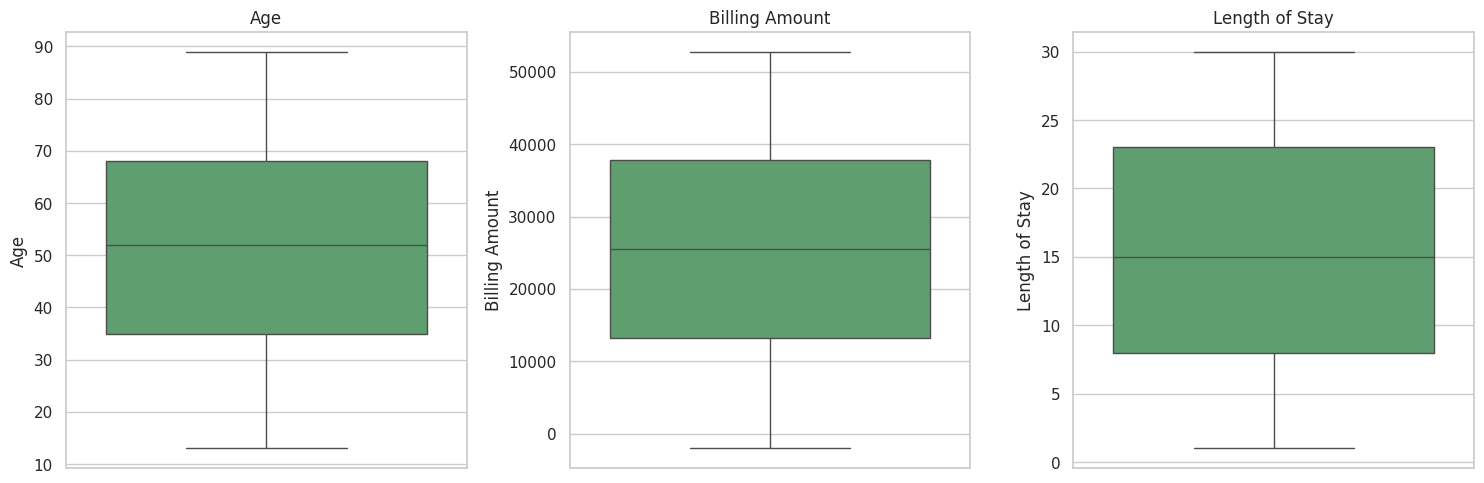

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col in zip(axes, ['Age','Billing Amount','Length of Stay']):
    sns.boxplot(y=df[col], ax=ax, color='#55A868')
    ax.set_title(col)
plt.tight_layout()
plt.show()


Zero IQR outliers in any numeric column — unusual, since real billing data almost always has some high-cost cases.

In [18]:
(df['Billing Amount'] < 0).sum()


np.int64(108)

## 10. Analyze Distributions

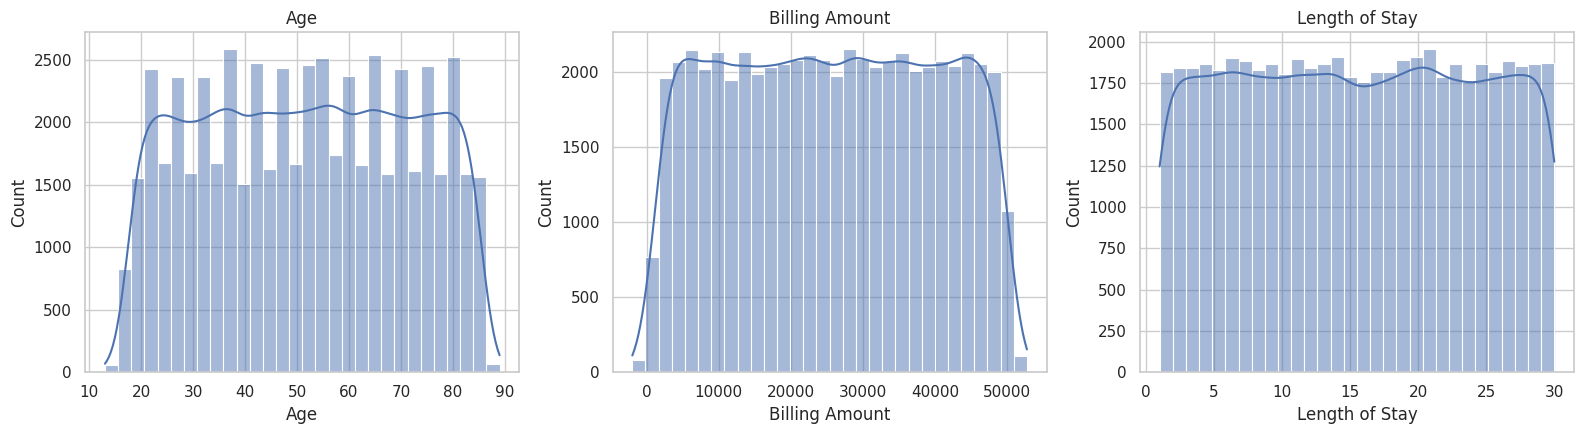

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for ax, col in zip(axes, ['Age','Billing Amount','Length of Stay']):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0', bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()


All three are close to flat/uniform, not bell-shaped or skewed.

## 11. Analyze Correlations

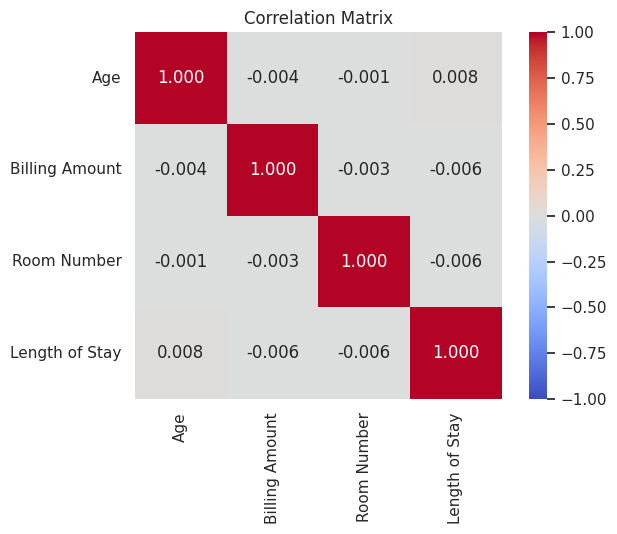

In [20]:
corr = df[num_cols].corr()
plt.figure(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [21]:
df.groupby('Medical Condition')['Billing Amount'].mean().round(0)


Medical Condition
Arthritis       25497.0
Asthma          25635.0
Cancer          25162.0
Diabetes        25638.0
Hypertension    25497.0
Obesity         25806.0
Name: Billing Amount, dtype: float64

All correlations are near zero. Average billing barely changes across medical condition or admission type.

## 12. Create Meaningful Visualizations

/tmp/ipykernel_481/3860215137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Admission Type', y='Length of Stay', palette='muted', ax=axes[1])


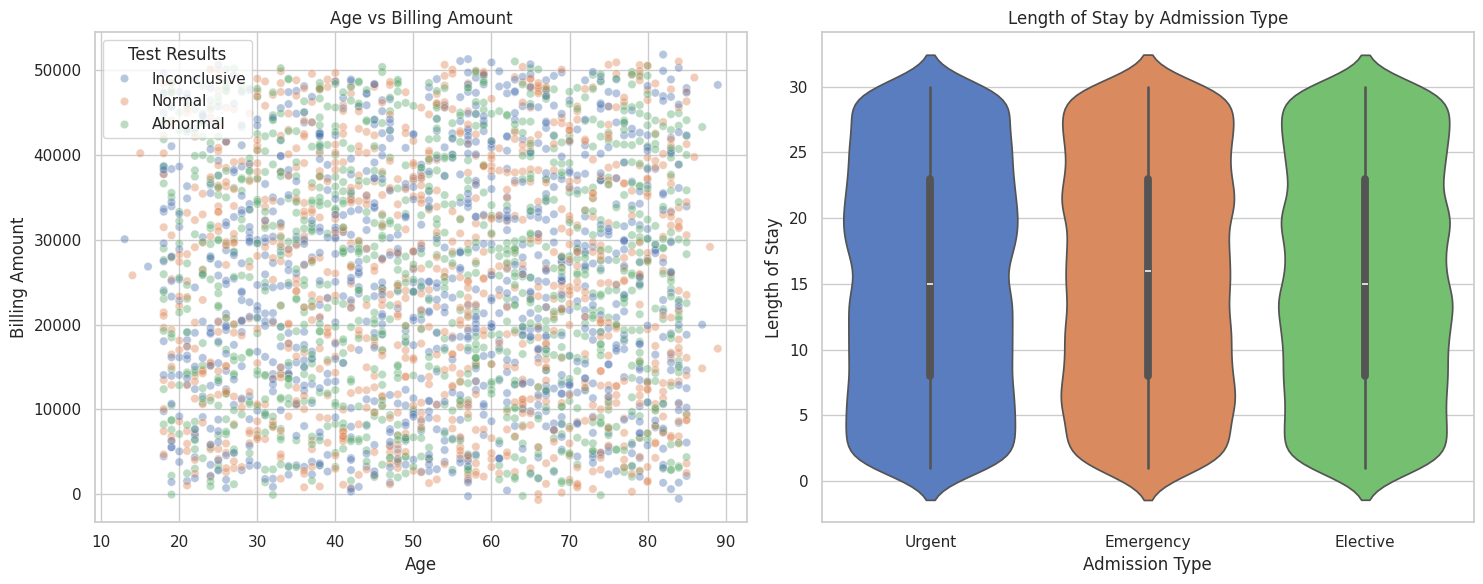

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
sns.scatterplot(data=df.sample(3000, random_state=1), x='Age', y='Billing Amount',
                 hue='Test Results', alpha=0.4, ax=axes[0], palette='deep')
axes[0].set_title('Age vs Billing Amount')
sns.violinplot(data=df, x='Admission Type', y='Length of Stay', palette='muted', ax=axes[1])
axes[1].set_title('Length of Stay by Admission Type')
plt.tight_layout()
plt.show()


Age vs Billing shows no trend. Length of Stay looks the same across all admission types.

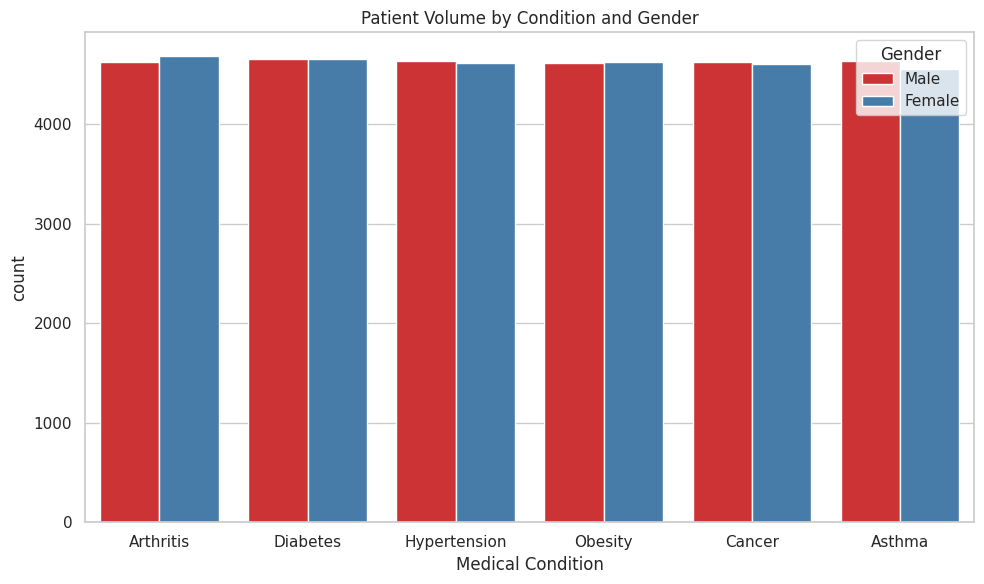

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Medical Condition', hue='Gender',
              order=df['Medical Condition'].value_counts().index, palette='Set1')
plt.title('Patient Volume by Condition and Gender')
plt.tight_layout()
plt.show()


Volume is even across every condition and gender.

## 13. Important Patterns

- Every numeric and categorical field is close to uniform/balanced.
- No relationship exists between any pair of numeric fields, or between category and outcome.
- Hospital and Name are unreliable as identifiers.


## 14. Business Insights

- Billing cannot be explained by condition, age, or admission type — a cost model isn't possible with current fields.
- No segment stands out for targeting since volume is evenly spread.
- Facility-level and patient-level analysis is blocked without a clean hospital field and a real patient ID.
- The overall pattern (no missing data, no outliers, flat distributions, balanced categories) points to synthetic rather than real-world data.


## 15. Recommendations for Preprocessing

1. Drop the 534 exact duplicate rows.
2. Decide how to handle the 108 negative billing values.
3. Parse dates and cast categoricals at ingestion time.
4. Normalize casing in Name, Doctor, Hospital.
5. Don't rely on Hospital or Name as identifiers until cleaned.
6. Plan encoding for categorical columns before modeling.
7. Plan scaling if using distance-based models.
8. Keep Length of Stay as an engineered feature.
9. No missing-value treatment needed for now.
10. Hold off on predictive modeling until richer features (procedure codes, severity) are available.
